In [1]:
import gc

gc.collect()


4

In [ ]:
# Install the main libraries we need for the tutorial
!pip -q install -U "transformers>=4.40" "sentence-transformers>=2.6" faiss-cpu gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.2/24.2 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.8 MB/s eta 0:00:00


In [ ]:
# Optional (only if you want OpenAI backend):
!pip -q install -U openai

In [ ]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 59.3 MB/s eta 0:00:00


In [ ]:
import os, textwrap
import numpy as np
#import faiss
import torch

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

print("torch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cpu
GPU available: False


#### I do not mix numpy>=2 packages in this environment if  plan to use medspaCy/SciSpaCy.

### I Use en_core_sci_sm mainly for NER / dictionary matching — the embeddings are small.

### For high-quality contextual embeddings, I use BioClinicalBERT separately

### clean install of compatible versions

In [ ]:
#!pip install spacy==3.4.4 scispacy==0.6.2 medspacy==1.3.1

In [ ]:
#!pip install medspacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.6/244.6 kB 8.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.9/69.9 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 408.5/408.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.1 MB/s eta 0:00:00
  Created wheel for medspacy: filename=medspacy-1.3.1-py3-none-any.whl size=313706 sha256=aeef2bf13619dfce71e79

In [ ]:
# !pip install spacy scispacy medspacy


In [ ]:
#!pip install medspacy==1.3.1

In [ ]:
# Install the small SciSpaCy model
#!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.1/en_core_sci_sm-0.5.1.tar.gz

In [ ]:
#!pip install transformers torch

In [ ]:
#!pip install scikit-multilearn

In [ ]:
#!pip install pyarrow

In [ ]:
#!pip install scikit-multilearn

In [ ]:
#!pip install iterative-stratification

# Install and Download Clinical Bert

In [ ]:
#!pip install transformers torch scikit-learn xgboost

# Install llama-cpp-python

In Colab:

In [ ]:
#!pip install llama-cpp-python

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Import Dependencies

In [4]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
#import spacy
#from spacy.matcher import PhraseMatcher
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from transformers import AutoTokenizer, AutoModel
import torch
#import medspacy


In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report
#from skmultilearn.model_selection import iterative_train_test_split
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import classification_report, roc_auc_score
#from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
from sklearn.metrics import (
    make_scorer, recall_score, f1_score, precision_score,
    roc_auc_score, hamming_loss, label_ranking_average_precision_score,
    multilabel_confusion_matrix, classification_report)

from xgboost import XGBClassifier
import re
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import label_ranking_average_precision_score
from sklearn.metrics import f1_score, accuracy_score, label_ranking_average_precision_score
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, label_ranking_average_precision_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Reading Dataset Columns

In [6]:

csv_path = '/content/drive/MyDrive/TMU_DM_Med_Jan2025R1.csv'

#  Read only the header (column names)
df1 = pd.read_csv(csv_path, nrows=0)
raw_cols = df1.columns.to_list()
print(len(raw_cols))
raw_cols

363


['Age_at_Exam',
 'Sex',
 'sBP',
 'sBP_Date',
 'BMI',
 'BMI_Date',
 'LDL',
 'LDL_Date',
 'HDL',
 'HDL_Date',
 'A1c',
 'A1c_Date',
 'TG',
 'TG_Date',
 'FBS',
 'FBS_Date',
 'Total_Cholesterol',
 'Total_Cholesterol_Lab_Date',
 'Diabetes',
 'Depression',
 'Depression_OnsetDate',
 'HTN',
 'HTN_OnsetDate',
 'OA',
 'OA_OnsetDate',
 'COPD',
 'COPD_Date',
 'Patient_ID',
 'DM_OnsetDate',
 'DM_Onset_Revised_1YrPrior',
 '[Amputation)',
 '[Amputation_Date]',
 '[Anxiety)',
 '[Anxiety_Date]',
 '[Arrhythmia)',
 '[Arrhythmia_Date]',
 '[AtrialFibrillation)',
 '[AtrialFibrillation_Date]',
 '[Blindness)',
 '[Blindness_Date]',
 '[CABG)',
 '[CABG_Date]',
 '[CAD)',
 '[CAD_Date]',
 '[Cancer)',
 '[Cancer_Date]',
 '[Cardiomyopathy)',
 '[Cardiomyopathy_Date]',
 '[Cataract)',
 '[Cataract_Date]',
 '[CKD)',
 '[CKD_Date]',
 '[Deceased)',
 '[Deceased_Date]',
 '[Depression)',
 '[Depression_Date]',
 '[DiabeticFootUlcer)',
 '[DiabeticFootUlcer_Date]',
 '[Dialysis)',
 '[Dialysis_Date]',
 '[Enteropathy)',
 '[Enteropathy_Da

# Fixing Column Names

In [7]:
def clean(col):
    col = re.sub(r"[\[\]\(\)]", "", col) # if replace with "" there would be two columns with name Depression
    #col = re.sub(r"[ /-]", "_", col)
    return col

clean_cols = [clean(col) for col in raw_cols]
print(len(clean_cols))
clean_cols

363


['Age_at_Exam',
 'Sex',
 'sBP',
 'sBP_Date',
 'BMI',
 'BMI_Date',
 'LDL',
 'LDL_Date',
 'HDL',
 'HDL_Date',
 'A1c',
 'A1c_Date',
 'TG',
 'TG_Date',
 'FBS',
 'FBS_Date',
 'Total_Cholesterol',
 'Total_Cholesterol_Lab_Date',
 'Diabetes',
 'Depression',
 'Depression_OnsetDate',
 'HTN',
 'HTN_OnsetDate',
 'OA',
 'OA_OnsetDate',
 'COPD',
 'COPD_Date',
 'Patient_ID',
 'DM_OnsetDate',
 'DM_Onset_Revised_1YrPrior',
 'Amputation',
 'Amputation_Date',
 'Anxiety',
 'Anxiety_Date',
 'Arrhythmia',
 'Arrhythmia_Date',
 'AtrialFibrillation',
 'AtrialFibrillation_Date',
 'Blindness',
 'Blindness_Date',
 'CABG',
 'CABG_Date',
 'CAD',
 'CAD_Date',
 'Cancer',
 'Cancer_Date',
 'Cardiomyopathy',
 'Cardiomyopathy_Date',
 'Cataract',
 'Cataract_Date',
 'CKD',
 'CKD_Date',
 'Deceased',
 'Deceased_Date',
 'Depression',
 'Depression_Date',
 'DiabeticFootUlcer',
 'DiabeticFootUlcer_Date',
 'Dialysis',
 'Dialysis_Date',
 'Enteropathy',
 'Enteropathy_Date',
 'ESRD',
 'ESRD_Date',
 'Gangrene',
 'Gangrene_Date',
 'Ga

# Fixing Duplicate column Names

In [8]:
duplicates = pd.Series(clean_cols)[pd.Series(clean_cols).duplicated()]
print(len(duplicates))
duplicates

1


,0
54,Depression


In [9]:
print(clean_cols[54])
clean_cols[54] = "Depression2"

Depression


# Reading Whole Dataset

In [10]:
dft = pd.read_csv(
    csv_path,
    names=clean_cols,  #  cleaned column names
    header=0, low_memory=False)

# Exploring Dataset

In [ ]:
dft.shape

(808921, 363)

In [ ]:
dft.head(2)

,Age_at_Exam,Sex,sBP,sBP_Date,BMI,BMI_Date,LDL,LDL_Date,HDL,HDL_Date,...,last_StartDate_b_R2_meglitinide,last_StopDate_b_R2_meglitinide,duration_b_R2_meglitinide_Days,total_b_R2_meglitinide_Records,DiagnosisText_orig,DateCreated,b_Retinopathy_combined,combined_with_Retinopathy,combined_with_b_R2_Retinopathy,combined_with_Retinopathy_and_b_R2_Retinopathy
0,69,Male,140.0,2010-03-18,26.0,2010-12-17,3.35,2010-03-06,1.03,2010-03-06,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
1,56,Female,120.0,2011-11-03,24.0,2011-11-03,4.01,2011-10-04,1.84,2011-10-04,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


In [ ]:
dft.sample(2)

,Age_at_Exam,Sex,sBP,sBP_Date,BMI,BMI_Date,LDL,LDL_Date,HDL,HDL_Date,...,last_StartDate_b_R2_meglitinide,last_StopDate_b_R2_meglitinide,duration_b_R2_meglitinide_Days,total_b_R2_meglitinide_Records,DiagnosisText_orig,DateCreated,b_Retinopathy_combined,combined_with_Retinopathy,combined_with_b_R2_Retinopathy,combined_with_Retinopathy_and_b_R2_Retinopathy
143093,52,Male,130.0,2010-01-14,25.22,2009-02-27,4.22,2010-04-07,1.38,2010-04-07,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
124949,77,Female,113.0,2011-09-27,24.02,2011-09-27,4.91,2011-09-23,2.11,2011-09-23,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


# Cheking Diabetes Column for Binary Values (1, 0)

In [ ]:
dft.Diabetes.sample(10)

,Diabetes
781271,1
176845,0
473715,0
392500,0
85958,0
644201,1
709576,1
646686,1
19148,0
106453,0


# Checking columns with text

In [11]:
cols = dft.columns[dft.columns.str.contains("Text", case=False)]

print(cols)

Index(['concatDiagnosisText_Orig', 'DiagnosisText_orig'], dtype='object')


# Choosing Rows with Diabetes

In [12]:
# choosing rows with Diabetes
dft = dft[dft['Diabetes'] == 1]

In [ ]:
'DiagnosisText' in dft.columns

False

# Aggregating on Patient ID

In [13]:
# Perform the aggregation


df = dft.groupby('Patient_ID').agg({

    # demographics
    'Age_at_Exam': 'max',
    'Sex': 'first',

    # TEXT columns → CONCAT
    'DiagnosisText_orig': lambda x: ' '.join(x.dropna().astype(str)),

    'concatDiagnosisText_Orig': lambda x: ' '.join(x.dropna().astype(str)),

    # LABEL columns → MAX (very important)
    'Neuropathy': 'max',
    'Retinopathy': 'max',
    'Nephropathy': 'max',
    'CKD': 'max',
    'ESRD': 'max',
    'DiabeticFootUlcer': 'max',
    'Amputation': 'max'

})

# Fill missing values with 0
df = df.fillna(0)

# Flatten the index so PID is a column again
df = df.reset_index()

In [ ]:
df.shape

(25920, 12)

# Process

### Clean text → Tokenize → Remove stopwords → Lemmatize → Stem → Vectorize (BoW / TF-IDF / n-grams)

# Extracting Columns related to research Question

In [14]:
df[cols].sample(2)

,concatDiagnosisText_Orig,DiagnosisText_orig
23525,,
92,,


In [ ]:
text1 = df['DiagnosisText_orig'].astype(str)
text2 = df['concatDiagnosisText_Orig'].astype(str)


# Cleaning Text

In [ ]:
# download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
#  Text Cleaning Function

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

# Apply cleaning

d_clean = text1.apply(clean_text)
cd_clean = text2.apply(clean_text)

# Remove stop words and Lematize

In [ ]:
#  Remove Stopwords and Lemmatize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def preprocess_text(text):

    tokens = text.split()
    clean_tokens = []
    seen = set()

    for word in tokens:

        if word not in stop_words:

            lemma = lemmatizer.lemmatize(word)
            stem = stemmer.stem(lemma)

            # remove repeated words
            if stem not in seen:

                clean_tokens.append(stem)
                seen.add(stem)

    return ' '.join(clean_tokens)

d_processed = d_clean.apply(preprocess_text)
cd_processed = cd_clean.apply(preprocess_text)



In [ ]:
df['DiagnosisText_clean'] = d_processed
df['concatDiagnosisText_clean'] = cd_processed

In [ ]:
df['DiagnosisText_clean'].head(4)

,DiagnosisText_clean
0,
1,
2,
3,


# Mask complications in text columns

In [ ]:
import re


complications = ['Neuropathy',
    'Retinopathy',
    'Nephropathy',
    'CKD',
    'ESRD',
    'DiabeticFootUlcer',
    'Amputation']

In [ ]:
def mask_labels(text):
    text = str(text).lower()

    for word in label_words:
        pattern = r"\b" + re.escape(word) + r"\b"
        text = re.sub(pattern, "[MASK]", text)

    return text

In [ ]:
df['DiagnosisText_clean'] = df['DiagnosisText_clean'].astype(str)
df['concatDiagnosisText_clean'] = df['concatDiagnosisText_clean'].astype(str)
# mask label words
df['DiagnosisText_clean'] = df['DiagnosisText_clean'].apply(mask_labels)
df['concatDiagnosisText_clean'] = df['concatDiagnosisText_clean'].apply(mask_labels)
# convert to list for tokenizer
# texts_masked = texts_masked.tolist()

# Bag of Word Vectorization (basic solution)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=3000, ngram_range=(1,1))

# Combine both columns for fitting
all_texts = pd.concat([df['DiagnosisText_clean'], df['concatDiagnosisText_clean']])

bow_vectorizer.fit(all_texts)  # fit once

# Transform each column separately
X_bow = bow_vectorizer.transform(df['DiagnosisText_clean'])
X_bowc = bow_vectorizer.transform(df['concatDiagnosisText_clean'])

# Now feature names match
print(len(bow_vectorizer.get_feature_names_out()), X_bow.shape[1], X_bowc.shape[1])

3000 3000 3000


# Find the most Frequent Words

In [ ]:
word_counts = X_bow.sum(axis=0)
words = bow_vectorizer.get_feature_names_out()
freq = [(word, word_counts[0, idx]) for idx, word in enumerate(words)]
freq_sorted = sorted(freq, key=lambda x: x[1], reverse=True)
print(freq_sorted[:20])

[('retinopathi', np.int64(210)), ('diabet', np.int64(155)), ('hypertens', np.int64(28)), ('dm', np.int64(21)), ('list', np.int64(19)), ('mild', np.int64(19)), ('retin', np.int64(19)), ('diseas', np.int64(18)), ('specif', np.int64(18)), ('xxx', np.int64(17)), ('background', np.int64(13)), ('eye', np.int64(13)), ('medic', np.int64(8)), ('exam', np.int64(7)), ('prolif', np.int64(7)), ('see', np.int64(7)), ('sinc', np.int64(7)), ('jan', np.int64(6)), ('nephropathi', np.int64(6)), ('cataract', np.int64(5))]


In [ ]:
cword_counts = X_bowc.sum(axis=0)
cwords = bow_vectorizer.get_feature_names_out()
freqc = [(word, cword_counts[0, idx]) for idx, word in enumerate(cwords)]
cfreq_sorted = sorted(freqc, key=lambda x: x[1], reverse=True)
print(cfreq_sorted[:20])

[('mellitu', np.int64(2375)), ('diabet', np.int64(1575)), ('includ', np.int64(1524)), ('type', np.int64(1458)), ('health', np.int64(1400)), ('disord', np.int64(1259)), ('examin', np.int64(1253)), ('benign', np.int64(1122)), ('complicationsdiabet', np.int64(1116)), ('system', np.int64(1059)), ('diseas', np.int64(994)), ('yet', np.int64(981)), ('pain', np.int64(884)), ('diag', np.int64(868)), ('medic', np.int64(838)), ('eg', np.int64(786)), ('illdefin', np.int64(754)), ('acut', np.int64(737)), ('hypertensiondiabet', np.int64(720)), ('metabol', np.int64(700))]


### *  .A1 is shortcut for .toarray().flatten()

In [ ]:
# X_bow is CountVectorizer output (sparse matrix)
# Use .A1 to safely get 1D array
word_counts = X_bow.sum(axis=0).A1

words = bow_vectorizer.get_feature_names_out()  # make sure it's the same vectorizer

# Check lengths match
assert len(words) == len(word_counts), "Feature count mismatch!"

# Create list of (word, count)
freq = list(zip(words, word_counts))

# Sort descending
freq_sorted = sorted(freq, key=lambda x: x[1], reverse=True)

print(freq_sorted[:20])

[('retinopathi', np.int64(210)), ('diabet', np.int64(155)), ('hypertens', np.int64(28)), ('dm', np.int64(21)), ('list', np.int64(19)), ('mild', np.int64(19)), ('retin', np.int64(19)), ('diseas', np.int64(18)), ('specif', np.int64(18)), ('xxx', np.int64(17)), ('background', np.int64(13)), ('eye', np.int64(13)), ('medic', np.int64(8)), ('exam', np.int64(7)), ('prolif', np.int64(7)), ('see', np.int64(7)), ('sinc', np.int64(7)), ('jan', np.int64(6)), ('nephropathi', np.int64(6)), ('cataract', np.int64(5))]


In [ ]:
# Convert to 1D array
cword_counts_array = np.array(X_bowc.sum(axis=0)).flatten()  # flatten to 1D

# Get feature names
cwords = bow_vectorizer.get_feature_names_out()

# Pair words with counts
freqc = [(word, cword_counts_array[idx]) for idx, word in enumerate(cwords)]

# Sort descending
cfreq_sorted = sorted(freqc, key=lambda x: x[1], reverse=True)

# Top 20
print(cfreq_sorted[:20])

[('mellitu', np.int64(2375)), ('diabet', np.int64(1575)), ('includ', np.int64(1524)), ('type', np.int64(1458)), ('health', np.int64(1400)), ('disord', np.int64(1259)), ('examin', np.int64(1253)), ('benign', np.int64(1122)), ('complicationsdiabet', np.int64(1116)), ('system', np.int64(1059)), ('diseas', np.int64(994)), ('yet', np.int64(981)), ('pain', np.int64(884)), ('diag', np.int64(868)), ('medic', np.int64(838)), ('eg', np.int64(786)), ('illdefin', np.int64(754)), ('acut', np.int64(737)), ('hypertensiondiabet', np.int64(720)), ('metabol', np.int64(700))]


# TF/IDF Vectorization (Better than BoW for clinical text.)

In [ ]:
tfidf_vectorizer = TfidfVectorizer(

    max_features=3000,

    ngram_range=(1,1)
)


In [ ]:
# Combine both columns for fitting
all_texts = pd.concat([df['DiagnosisText_clean'], df['concatDiagnosisText_clean']])

tfidf_vectorizer.fit(all_texts)  # fit once on all text

# Transform each column separately
X_tfidf = tfidf_vectorizer.transform(df['DiagnosisText_clean'])
X_tfidf_concat = tfidf_vectorizer.transform(df['concatDiagnosisText_clean'])

# Now vocab is consistent
print("Vocabulary length:", len(tfidf_vectorizer.get_feature_names_out()))
print(tfidf_vectorizer.get_feature_names_out()[:20])  # first 20 words

Vocabulary length: 3000
['aaa' 'ab' 'abd' 'abdo' 'abdomen' 'abdomenpelvi' 'abdomin' 'abl' 'ablat'
 'abn' 'abnorm' 'abort' 'abortdiabet' 'abortoth' 'abras' 'abscess'
 'abscessannu' 'abscesscellul' 'abscesscommon' 'abscessdiabet']


# Find most important TF-IDF words

In [ ]:
tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()

words = tfidf_vectorizer.get_feature_names_out()

important_words = sorted(

    zip(words, tfidf_scores),

    key=lambda x: x[1],

    reverse=True
)

print(important_words[:20])

[('retinopathi', np.float64(0.005140265083841215)), ('diabet', np.float64(0.0026810866359365175)), ('hypertens', np.float64(0.00044643191028553094)), ('background', np.float64(0.0003671645537920841)), ('list', np.float64(0.00034349778001277703)), ('specif', np.float64(0.00033747854078649414)), ('dm', np.float64(0.00033633490425422617)), ('mild', np.float64(0.00032779735815976384)), ('retin', np.float64(0.00032494960458803154)), ('xxx', np.float64(0.00021293631374956785)), ('diseas', np.float64(0.0002074853388854232)), ('prolif', np.float64(0.00020010139204328033)), ('eye', np.float64(0.00017986389409277483)), ('nephropathi', np.float64(0.00011384218447182486)), ('hemorrhag', np.float64(0.00010275722217468428)), ('exam', np.float64(9.317254391236692e-05)), ('follow', np.float64(8.476097792497895e-05)), ('no', np.float64(8.241451779899433e-05)), ('see', np.float64(7.91041525504829e-05)), ('cataract', np.float64(7.801681535594406e-05))]


# BEST  for  CPCSSN diabetic complications

In [ ]:
TfidfVectorizer(ngram_range=(1,3))

TfidfVectorizer(ngram_range=(1, 3))

# N-Grams (VERY IMPORTANT for clinical meaning)

Detect phrases like:

• diabetic neuropathy
• kidney failure
• foot ulcer

## Unigram + Bigram + Trigram

In [ ]:
target_cols = ['Retinopathy', 'Neuropathy', 'Nephropathy', 'CKD',
               'ESRD', 'DiabeticFootUlcer', 'Amputation']

# Filter rows with at least one target label
df_with_labels = df[df[target_cols].sum(axis=1) > 0]

print(f"Total rows with at least one target label: {len(df_with_labels)}")

# Sample 6000 rows
sample_size = 6000
if len(df_with_labels) > sample_size:
    df_sample = df_with_labels.sample(n=sample_size, random_state=42)
else:
    df_sample = df_with_labels.copy()

Total rows with at least one target label: 283


In [ ]:
df = df_sample.copy()

In [ ]:
df_sample.shape


(283, 14)

In [ ]:
#  text columns are strings and handle missing values
df['DiagnosisText_clean'] = df['DiagnosisText_clean'].fillna("").astype(str)
df['concatDiagnosisText_clean'] = df['concatDiagnosisText_clean'].fillna("").astype(str)

# Combine both columns
df['combined_text'] = df['DiagnosisText_clean'] + " " + df['concatDiagnosisText_clean']



# Create vectorizer
ngram_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,3)
)

# Fit on sample
ngram_vectorizer.fit(df['combined_text'])

# Transform sample
X_ngram = ngram_vectorizer.transform(df['combined_text'])

# Feature names
feature_names = ngram_vectorizer.get_feature_names_out()

print(X_ngram.shape)

(283, 5000)


# n-grams / TF-IDF → find statistically important phrases



# complete integrated pipeline for CPCSSN:

### * Clean → Tokenize → Stopwords → Lemmatize → Stem

### * TF-IDF with n-grams



# Load Bio_ClinicalBERT

In [ ]:
model_name = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

# Generate embeddings from DiagnosisText_orig

In [ ]:
def get_bert_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    outputs = model(**inputs)

    embedding = outputs.last_hidden_state[:, 0, :].detach().numpy()

    return embedding.flatten()

# Apply to columns

In [ ]:
bert_embeddings = df['combined_text'].apply(get_bert_embedding)


In [ ]:
X_bert = np.vstack(bert_embeddings)

In [ ]:
print(X_bert.shape)

# (n_samples, 768)

(283, 768)


# Classification into 7 complications

In [ ]:
# Define  multi-label target columns
labels = [
    'Retinopathy',
    'Neuropathy',
    'Nephropathy',
    'CKD',
    'ESRD',
    'DiabeticFootUlcer',
    'Amputation'
]

# Features (text)
X = X_ngram  # TF-IDF / n-grams

# Labels (multi-label)
y = df[labels].fillna(0).astype(int)  # replace NaNs and ensure integer 0/1

print(y.head())
print(y.isna().sum())  # should all be 0

     Retinopathy  Neuropathy  Nephropathy  CKD  ESRD  DiabeticFootUlcer  \
178            0           0            0    1     0                  0   
263            0           1            0    0     0                  0   
279            0           1            0    0     0                  0   
367            0           1            0    0     0                  1   
378            1           0            0    0     0                  0   

     Amputation  
178           0  
263           0  
279           0  
367           1  
378           0  
Retinopathy          0
Neuropathy           0
Nephropathy          0
CKD                  0
ESRD                 0
DiabeticFootUlcer    0
Amputation           0
dtype: int64


# Split into Train , Validation, Test (70, 15, 15)

In [ ]:
# Step 1: Extract 70% for training. 30% remains for (Val + Test).

# First split: Train (70%) and Temp (30%)

X_train, X_temp, y_train, y_temp = train_test_split(

    X, y,

    test_size=0.30,

    random_state=42,

    stratify=y.values.any(axis=1)

)

# Second split: Validation (15%) and Test (15%)

X_val, X_test, y_val, y_test = train_test_split(

    X_temp, y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp.values.any(axis=1)

)



In [ ]:
print(X_train.shape[0], X_val.shape[0], X_test.shape[0])

198 42 43


In [ ]:
total = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
print("Total samples:", total)
print("Matches original dataset:", total == len(df))

Total samples: 283
Matches original dataset: True


# Logistic Regression (GOOD baseline)

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, hamming_loss, roc_auc_score, classification_report, multilabel_confusion_matrix

# Stratified K-Fold for multi-label: stratify by at least one positive label
stratify_labels = (y.sum(axis=1) > 0).astype(int)  # 1 if any disease present

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics
metrics_list = []



In [ ]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X, stratify_labels)):
    print(f"\n--- Fold {fold+1} ---")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Multi-label classifier
    model = OneVsRestClassifier(LogisticRegression(solver='liblinear', max_iter=500))
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    # Metrics
    f1 = f1_score(y_val, y_pred, average='macro')
    hamming = hamming_loss(y_val, y_pred)
    try:
        auc_macro = roc_auc_score(y_val, y_prob, average='macro')
        auc_micro = roc_auc_score(y_val, y_prob, average='micro')
    except:
        auc_macro, auc_micro = np.nan, np.nan

    print(f"F1 (macro): {f1:.3f}")
    print(f"Hamming Loss: {hamming:.3f}")
    print(f"ROC-AUC (macro): {auc_macro:.3f}")
    print(f"ROC-AUC (micro): {auc_micro:.3f}")

    # Confusion matrices per label
    cms = multilabel_confusion_matrix(y_val, y_pred)
    for i, col in enumerate(target_cols):
        print(f"\nConfusion matrix for {col}:\n{cms[i]}")

    # Classification report
    print("\nClassification report:\n", classification_report(y_val, y_pred, zero_division=0))

    metrics_list.append({
        'fold': fold+1,
        'f1_macro': f1,
        'hamming': hamming,
        'roc_auc_macro': auc_macro,
        'roc_auc_micro': auc_micro
    })

# Average metrics across folds
metrics_df = pd.DataFrame(metrics_list)
print("\nAverage Metrics Across Folds:\n", metrics_df.mean())


--- Fold 1 ---
F1 (macro): 0.105
Hamming Loss: 0.130
ROC-AUC (macro): 0.857
ROC-AUC (micro): 0.855

Confusion matrix for Retinopathy:
[[47  0]
 [10  0]]

Confusion matrix for Neuropathy:
[[ 9 19]
 [ 1 28]]

Confusion matrix for Nephropathy:
[[52  0]
 [ 5  0]]

Confusion matrix for CKD:
[[54  0]
 [ 3  0]]

Confusion matrix for ESRD:
[[55  0]
 [ 2  0]]

Confusion matrix for DiabeticFootUlcer:
[[54  0]
 [ 3  0]]

Confusion matrix for Amputation:
[[48  0]
 [ 9  0]]

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.60      0.97      0.74        29
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         9

   micro avg       0.60      0.46      0.52        61
   macro avg       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not def

F1 (macro): 0.116
Hamming Loss: 0.095
ROC-AUC (macro): nan
ROC-AUC (micro): 0.882

Confusion matrix for Retinopathy:
[[51  0]
 [ 6  0]]

Confusion matrix for Neuropathy:
[[ 3 16]
 [ 1 37]]

Confusion matrix for Nephropathy:
[[50  0]
 [ 7  0]]

Confusion matrix for CKD:
[[51  0]
 [ 6  0]]

Confusion matrix for ESRD:
[[57  0]
 [ 0  0]]

Confusion matrix for DiabeticFootUlcer:
[[57  0]
 [ 0  0]]

Confusion matrix for Amputation:
[[55  0]
 [ 2  0]]

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.70      0.97      0.81        38
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         2

   micro avg       0.70      0.63      0.66        59
   macro avg       0.10      0.14     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    f1_score, hamming_loss, classification_report, multilabel_confusion_matrix
)

# Metrics per label
for i, label in enumerate(y_train.columns):
    print(f"Label: {label}")
    f1 = f1_score(y_val.iloc[:,i], y_pred[:,i])
    hamming = hamming_loss(y_val.iloc[:,i], y_pred[:,i])
    roc_auc = roc_auc_score(y_val.iloc[:,i], y_prob[:,i])
    print(f"  F1-score: {f1:.3f}")
    print(f"  Hamming Loss: {hamming:.3f}")
    print(f"  ROC-AUC: {roc_auc:.3f}")
    print("-"*30)

Label: Retinopathy
  F1-score: 0.000
  Hamming Loss: 0.071
  ROC-AUC: 1.000
------------------------------
Label: Neuropathy
  F1-score: 0.857
  Hamming Loss: 0.214
  ROC-AUC: 0.799
------------------------------
Label: Nephropathy
  F1-score: 0.000
  Hamming Loss: 0.071
  ROC-AUC: 0.649
------------------------------
Label: CKD
  F1-score: 0.000
  Hamming Loss: 0.036
  ROC-AUC: 0.731
------------------------------
Label: ESRD
  F1-score: 0.000
  Hamming Loss: 0.000
  ROC-AUC: nan
------------------------------
Label: DiabeticFootUlcer
  F1-score: 0.000
  Hamming Loss: 0.000
  ROC-AUC: nan
------------------------------
Label: Amputation
  F1-score: 0.000
  Hamming Loss: 0.196
  ROC-AUC: 0.887
------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that cas

# Confusion Matrices per label

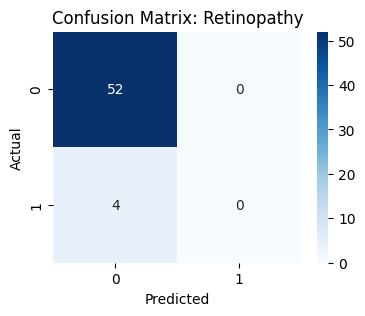

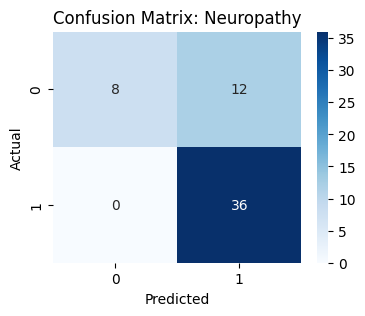

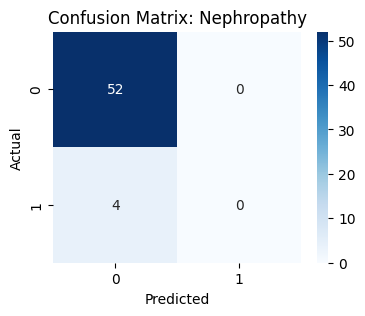

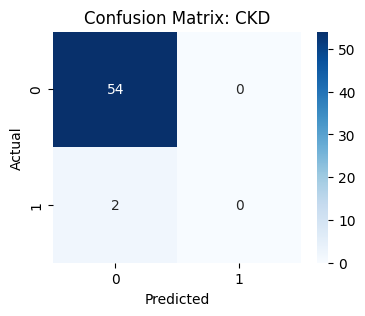

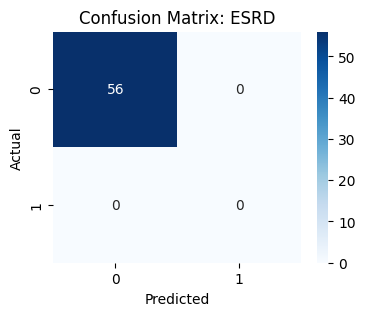

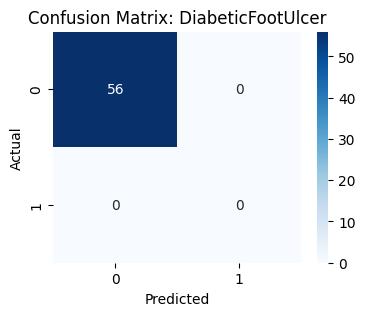

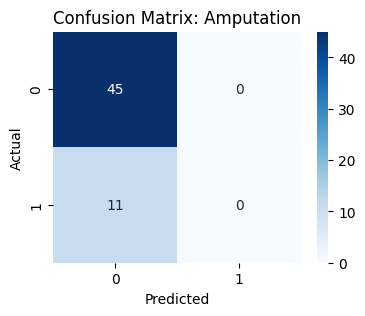

In [ ]:

cm_list = multilabel_confusion_matrix(y_val, y_pred)
for i, label in enumerate(y_train.columns):
    cm = cm_list[i]
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Train final model on full train+val set


In [ ]:
# Combine train + validation for  final training
X_full_train = np.vstack([X_train.toarray(), X_val.toarray()])
y_full_train = pd.concat([y_train, y_val])

final_model = OneVsRestClassifier(LogisticRegression(solver='liblinear'))
final_model.fit(X_full_train, y_full_train)

OneVsRestClassifier(estimator=LogisticRegression(solver='liblinear'))

# Logistic Regression Test Evaluation

In [ ]:
y_test_pred = final_model.predict(X_test)

# Metrics
f1_macro = f1_score(y_test, y_test_pred, average='macro')
f1_micro = f1_score(y_test, y_test_pred, average='micro')
acc = accuracy_score(y_test, y_test_pred)
hamming = hamming_loss(y_test, y_test_pred)
roc_auc_micro = roc_auc_score(y_test, final_model.predict_proba(X_test), average='micro')
roc_auc_macro = roc_auc_score(y_test, final_model.predict_proba(X_test), average='macro')

print("\n===== Test Set Metrics =====")
print(f"Accuracy: {acc:.3f}")
print(f"F1 (macro): {f1_macro:.3f}")
print(f"F1 (micro): {f1_micro:.3f}")
print(f"Hamming Loss: {hamming:.3f}")
print(f"ROC-AUC (macro): {roc_auc_macro:.3f}")
print(f"ROC-AUC (micro): {roc_auc_micro:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=y_test.columns))




===== Test Set Metrics =====
Accuracy: 0.628
F1 (macro): 0.205
F1 (micro): 0.756
Hamming Loss: 0.066
ROC-AUC (macro): nan
ROC-AUC (micro): 0.984

Classification Report:
                   precision    recall  f1-score   support

      Retinopathy       0.00      0.00      0.00         7
       Neuropathy       0.88      1.00      0.94        29
      Nephropathy       0.00      0.00      0.00         5
              CKD       0.00      0.00      0.00         0
             ESRD       0.00      0.00      0.00         0
DiabeticFootUlcer       0.00      0.00      0.00         0
       Amputation       1.00      0.33      0.50         6

        micro avg       0.89      0.66      0.76        47
        macro avg       0.27      0.19      0.21        47
     weighted avg       0.67      0.66      0.64        47
      samples avg       0.72      0.67      0.69        47



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no

# Confusion matrices per label

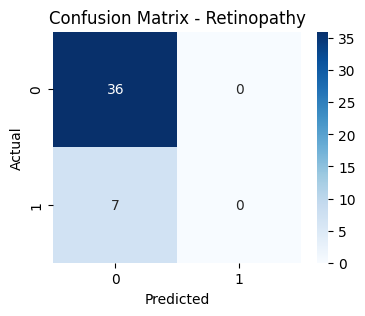

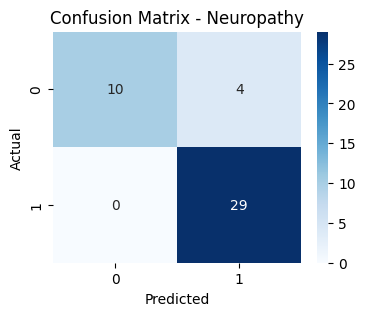

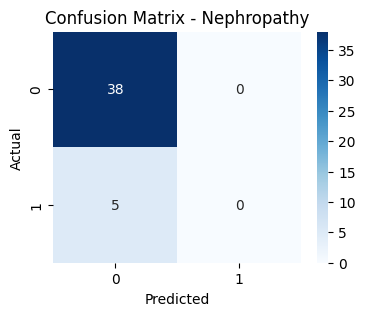

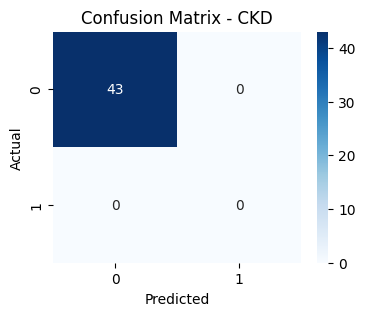

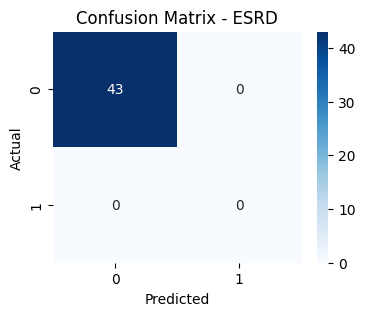

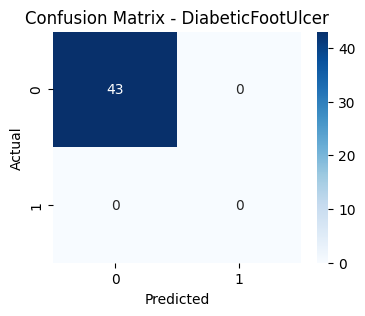

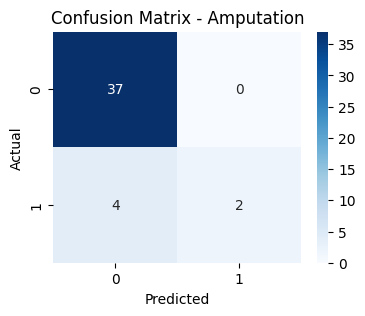

In [ ]:

cm_list = multilabel_confusion_matrix(y_test, y_test_pred)
for i, label in enumerate(y_test.columns):
    cm = cm_list[i]
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



#  ROC Curves per label


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


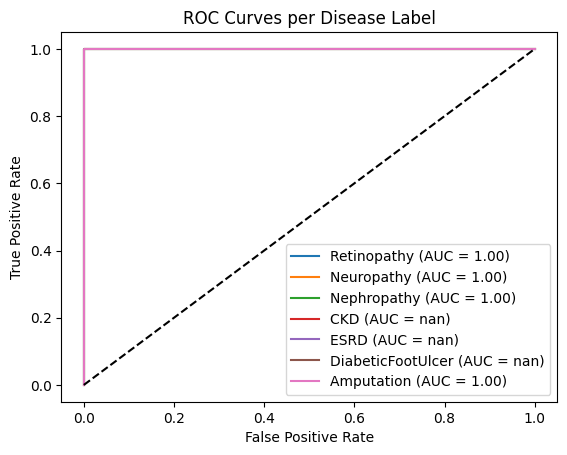

In [ ]:

from sklearn.metrics import roc_curve, auc

y_prob = final_model.predict_proba(X_test)

for i, label in enumerate(y_test.columns):
    fpr, tpr, _ = roc_curve(y_test[label], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per Disease Label")
plt.legend()
plt.show()

# XGBoost _Validation

In [ ]:
 #Train OneVsRest XGBoost on training set


xgb_model = OneVsRestClassifier(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
)

xgb_model.fit(X_train, y_train)

# Predict on test set

y_val_pred = xgb_model.predict(X_val)
y_val_prob = xgb_model.predict_proba(X_val)  # probabilities needed for ROC-AUC


# Evaluate metrics

f1_macro = f1_score(y_val, y_val_pred, average='macro')
f1_micro = f1_score(y_val, y_val_pred, average='micro')
acc = accuracy_score(y_val, y_val_pred)
hamming = hamming_loss(y_val, y_val_pred)
roc_auc_micro = roc_auc_score(y_val, y_val_prob, average='micro')
roc_auc_macro = roc_auc_score(y_val, y_val_prob, average='macro')

print("===== XGBoost Multi-label Metrics =====")
print(f"Accuracy: {acc:.3f}")
print(f"F1 (macro): {f1_macro:.3f}")
print(f"F1 (micro): {f1_micro:.3f}")
print(f"Hamming Loss: {hamming:.3f}")
print(f"ROC-AUC (macro): {roc_auc_macro:.3f}")
print(f"ROC-AUC (micro): {roc_auc_micro:.3f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=y_val.columns))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:19:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:19:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:19:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:19:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


===== XGBoost Multi-label Metrics =====
Accuracy: 0.679
F1 (macro): 0.360
F1 (micro): 0.762
Hamming Loss: 0.064
ROC-AUC (macro): nan
ROC-AUC (micro): 0.943

Classification Report:
                   precision    recall  f1-score   support

      Retinopathy       1.00      1.00      1.00         4
       Neuropathy       0.79      0.83      0.81        36
      Nephropathy       0.00      0.00      0.00         4
              CKD       0.00      0.00      0.00         2
             ESRD       0.00      0.00      0.00         0
DiabeticFootUlcer       0.00      0.00      0.00         0
       Amputation       1.00      0.55      0.71        11

        micro avg       0.83      0.70      0.76        57
        macro avg       0.40      0.34      0.36        57
     weighted avg       0.76      0.70      0.72        57
      samples avg       0.71      0.71      0.70        57



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no

# XGBoost Test

In [ ]:
# Combine train + validation for  final training
X_full_train = np.vstack([X_train.toarray(), X_val.toarray()])
y_full_train = pd.concat([y_train, y_val])

final_model = xgb_model = OneVsRestClassifier(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
)
final_model.fit(X_full_train, y_full_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

OneVsRestClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=-1,
                                            num_parallel_tree=None, ...))

In [ ]:
xgb_model.fit(X_train, y_train)

# ==============================
# Predict on test set
y_test_pred = xgb_model.predict(X_test)
y_test_prob = xgb_model.predict_proba(X_test)  # probabilities needed for ROC-AUC


# Evaluate metrics

f1_macro = f1_score(y_test, y_test_pred, average='macro')
f1_micro = f1_score(y_test, y_test_pred, average='micro')
acc = accuracy_score(y_test, y_test_pred)
hamming = hamming_loss(y_test, y_test_pred)
roc_auc_micro = roc_auc_score(y_test, y_test_prob, average='micro')
roc_auc_macro = roc_auc_score(y_test, y_test_prob, average='macro')

print("===== XGBoost Multi-label Metrics =====")
print(f"Accuracy: {acc:.3f}")
print(f"F1 (macro): {f1_macro:.3f}")
print(f"F1 (micro): {f1_micro:.3f}")
print(f"Hamming Loss: {hamming:.3f}")
print(f"ROC-AUC (macro): {roc_auc_macro:.3f}")
print(f"ROC-AUC (micro): {roc_auc_micro:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=y_test.columns))



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

===== XGBoost Multi-label Metrics =====
Accuracy: 0.930
F1 (macro): 0.532
F1 (micro): 0.967
Hamming Loss: 0.010
ROC-AUC (macro): nan
ROC-AUC (micro): 0.999

Classification Report:
                   precision    recall  f1-score   support

      Retinopathy       1.00      0.86      0.92         7
       Neuropathy       1.00      1.00      1.00        29
      Nephropathy       1.00      0.80      0.89         5
              CKD       0.00      0.00      0.00         0
             ESRD       0.00      0.00      0.00         0
DiabeticFootUlcer       0.00      0.00      0.00         0
       Amputation       1.00      0.83      0.91         6

        micro avg       1.00      0.94      0.97        47
        macro avg       0.57      0.50      0.53        47
     weighted avg       1.00      0.94      0.97        47
      samples avg       0.93      0.93      0.93        47



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no

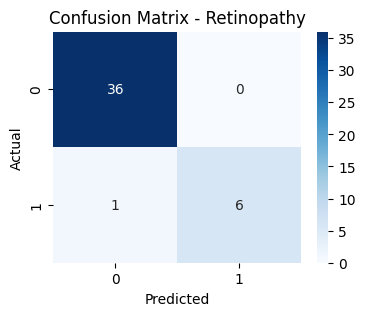

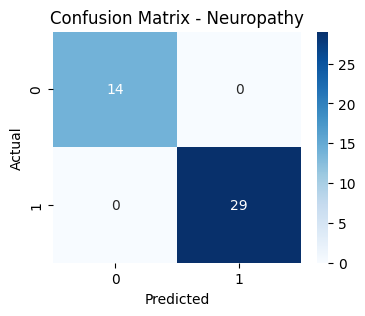

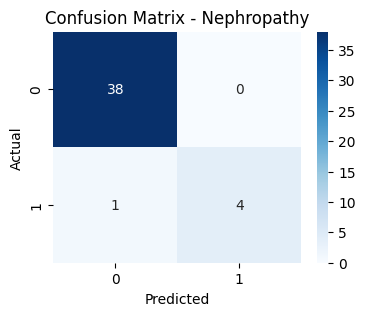

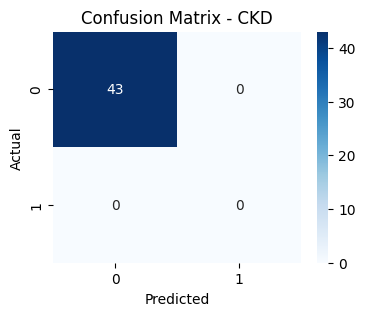

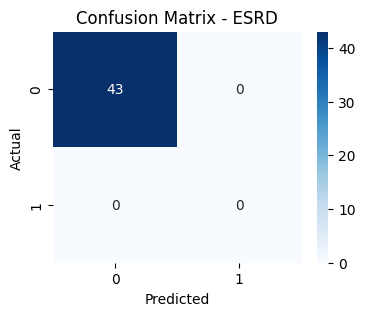

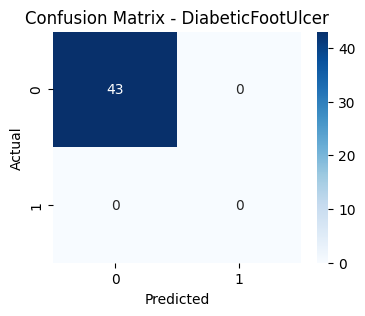

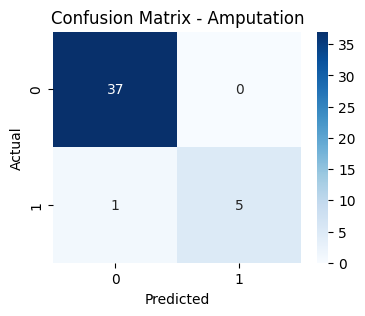

In [ ]:
# Confusion matrices per label

cm_list = multilabel_confusion_matrix(y_test, y_test_pred)
for i, label in enumerate(y_test.columns):
    cm = cm_list[i]
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


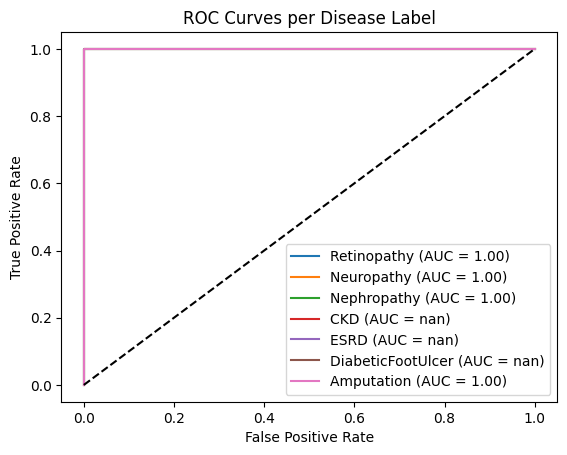

In [ ]:
# ROC curves per label

for i, label in enumerate(y_test.columns):
    fpr, tpr, _ = roc_curve(y_test[label], y_test_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per Disease Label")
plt.legend()
plt.show()

DiagnosisText_orig

        ↓

TF-IDF n-grams

        ↓

BioClinicalBERT embeddings

        ↓

Combine features

        ↓
        
XGBoost classifier

# XGBoost (Bert embedding + n-grams)

In [ ]:
from scipy.sparse import csr_matrix, hstack


# Make sure X_bert is 2D numpy array
if not isinstance(X_bert, np.ndarray):
    X_bert = np.array(X_bert)

# Convert dense BERT embeddings to sparse matrix to concatenate with TF-IDF
X_bert_sparse = csr_matrix(X_bert)

# Combine TF-IDF/ngram sparse matrix + BERT embeddings
X_final = hstack([X_ngram, X_bert_sparse])

print("Combined feature shape:", X_final.shape)

Combined feature shape: (283, 5768)


In [ ]:
# Create a boolean column: does this row have at least one disease?
stratify_col = (y.sum(axis=1) > 0).astype(int)

# Step 1: Split 70% train, 30% temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_final, y,
    test_size=0.30,
    random_state=42,
    stratify=stratify_col
)

# Step 2: Split temp into 50/50 → 15% val, 15% test
stratify_temp = (y_temp.sum(axis=1) > 0).astype(int)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=stratify_temp
)

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Shapes:
X_train: (198, 5768) y_train: (198, 7)
X_val: (42, 5768) y_val: (42, 7)
X_test: (43, 5768) y_test: (43, 7)


In [ ]:

xgb_model = OneVsRestClassifier(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
)

xgb_model.fit(X_train, y_train)


# Predict & evaluate
y_pred = xgb_model.predict(X_val)
y_prob = xgb_model.predict_proba(X_val)

#  metrics
f1_macro = f1_score(y_val, y_pred, average='macro')
f1_micro = f1_score(y_val, y_pred, average='micro')
acc = accuracy_score(y_val, y_pred)
hamming = hamming_loss(y_val, y_pred)
roc_auc_micro = roc_auc_score(y_val, y_prob, average='micro')
roc_auc_macro = roc_auc_score(y_val, y_prob, average='macro')

print(f"Accuracy: {acc:.3f}")
print(f"F1 (macro): {f1_macro:.3f}")
print(f"F1 (micro): {f1_micro:.3f}")
print(f"Hamming Loss: {hamming:.3f}")
print(f"ROC-AUC (macro): {roc_auc_macro:.3f}")
print(f"ROC-AUC (micro): {roc_auc_micro:.3f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:38:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:38:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:38:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:38:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Accuracy: 0.667
F1 (macro): 0.357
F1 (micro): 0.778
Hamming Loss: 0.068
ROC-AUC (macro): nan
ROC-AUC (micro): 0.891


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)

# Example metrics
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')
acc = accuracy_score(y_test, y_pred)
hamming = hamming_loss(y_test, y_pred)
roc_auc_micro = roc_auc_score(y_test, y_prob, average='micro')
roc_auc_macro = roc_auc_score(y_test, y_prob, average='macro')

print(f"Accuracy: {acc:.3f}")
print(f"F1 (macro): {f1_macro:.3f}")
print(f"F1 (micro): {f1_micro:.3f}")
print(f"Hamming Loss: {hamming:.3f}")
print(f"ROC-AUC (macro): {roc_auc_macro:.3f}")
print(f"ROC-AUC (micro): {roc_auc_micro:.3f}")

Accuracy: 0.651
F1 (macro): 0.362
F1 (micro): 0.783
Hamming Loss: 0.066
ROC-AUC (macro): nan
ROC-AUC (micro): 0.929


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


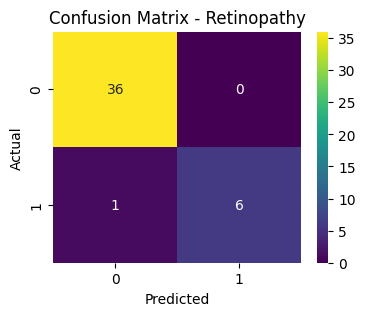

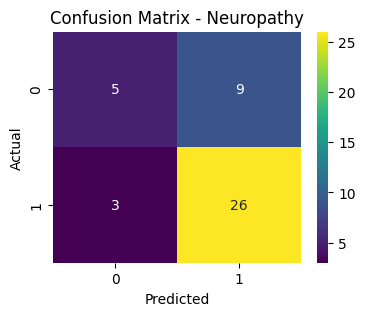

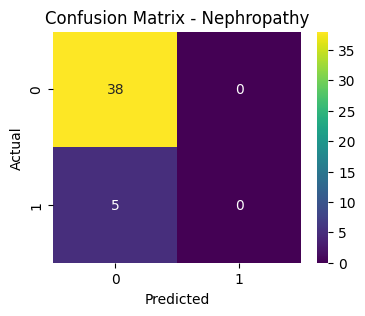

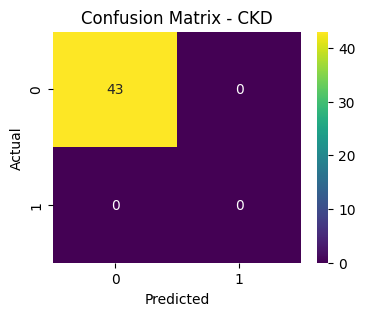

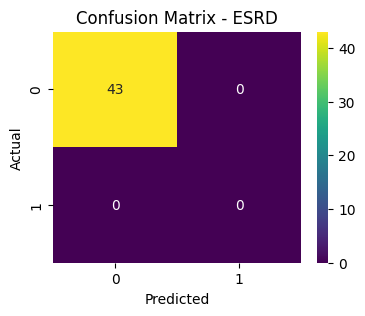

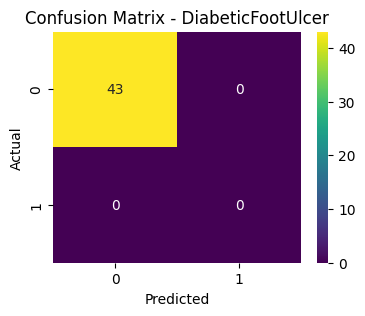

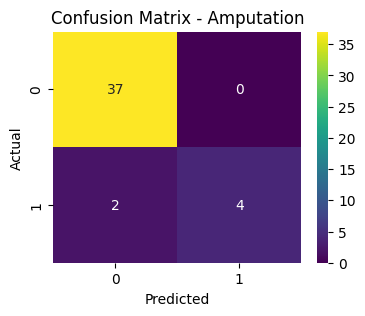

In [ ]:
# Compute confusion matrices per label
cm_list = multilabel_confusion_matrix(y_test, y_pred)

# Plot each label separately
for i, label in enumerate(y_test.columns):
    cm = cm_list[i]
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.title(f'Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


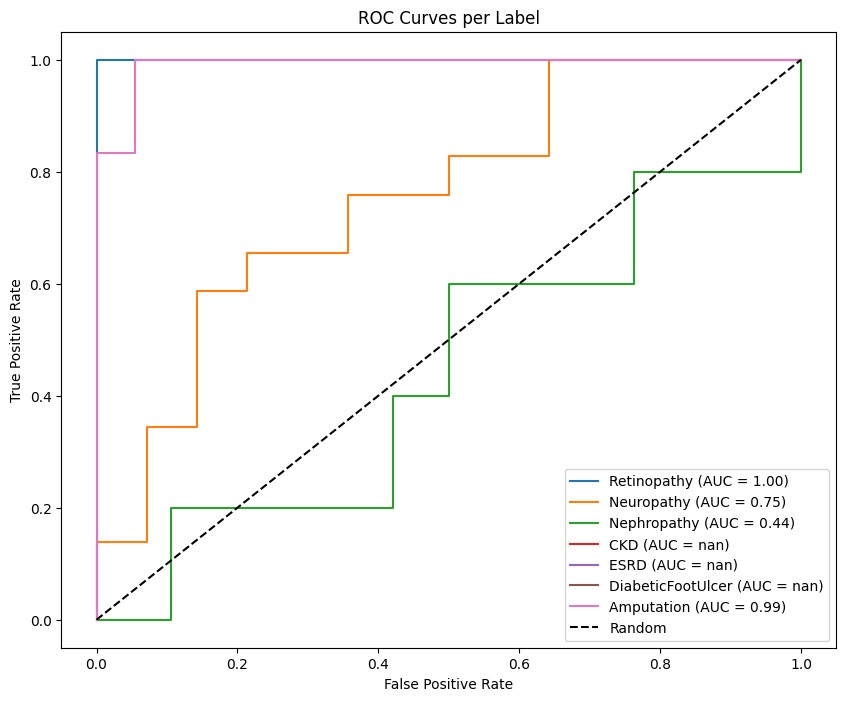

In [ ]:
# ROC Curves per label
plt.figure(figsize=(10,8))
for i, label in enumerate(y_test.columns):
    fpr, tpr, _ = roc_curve(y_test.iloc[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1], 'k--', label='Random')
plt.title('ROC Curves per Label')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Pure Bio_ClinicalBERT fine-tuning (ADVANCED)


* fine-tune BERT directly


In [ ]:
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
#from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, multilabel_confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)



Using device: cuda


#  Load Data

In [ ]:

# df['combined_text'] (text column)
# df[target_cols] (multi-label 0/1 columns)
target_cols = ['Retinopathy','Neuropathy','Nephropathy','CKD','ESRD','DiabeticFootUlcer','Amputation']

# Combine text columns
texts = df['DiagnosisText_clean'] + " " + df['concatDiagnosisText_clean']

# Example split
X = texts.fillna("").astype(str)
y = df[target_cols].fillna(0).values  # numpy array for multi-label


# Train/Val/Test split 70/15/15


In [ ]:

# Train / validation / test split
from sklearn.model_selection import train_test_split

y = df[target_cols].fillna(0).values  # multi-label 0/1

# Stratify by whether any disease label is present
stratify_col = (y.sum(axis=1) > 0).astype(int)

X_train, X_temp_texts, y_train, y_temp = train_test_split(
    texts.tolist(),  # <-- convert Series to list
    y,
    test_size=0.30,
    random_state=42,
    stratify=stratify_col
)

stratify_temp = (y_temp.sum(axis=1) > 0).astype(int)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp_texts,  # already list
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=stratify_temp
)


#  Tokenizer


In [ ]:

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

texts = texts.astype(str).tolist()  # convert Series to list of strings


#  tokenize
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    max_length=128,  # or whatever length you want
    return_tensors="pt"
)



In [ ]:
type(texts)


list

In [ ]:
max_len = 128

def encode_texts(texts, tokenizer, max_len=max_len):
    return tokenizer(list(texts),
                     padding='max_length',
                     truncation=True,
                     max_length=max_len,
                     return_tensors='pt')

train_encodings = encode_texts(X_train, tokenizer)
val_encodings = encode_texts(X_val, tokenizer)
test_encodings = encode_texts(X_test, tokenizer)

# Dataset


In [ ]:
import torch
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels  # numpy array or tensor

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # return dictionary of input_ids, attention_mask + labels
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        return item, label

In [ ]:
import torch
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        """
        encodings: dict from tokenizer (input_ids, attention_mask)
        labels: numpy array or tensor of shape [num_samples, num_labels]
        """
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.float)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # return input_ids, attention_mask, and labels
        item = {key: val[idx] for key, val in self.encodings.items()}  # input_ids & attention_mask
        item['labels'] = self.labels[idx]
        return item

# Create Dataloader

In [ ]:
from torch.utils.data import DataLoader

train_dataset = TextDataset(train_encodings, y_train)
val_dataset = TextDataset(val_encodings, y_val)
test_dataset = TextDataset(test_encodings, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = TextDataset(train_encodings, y_train)
val_dataset   = TextDataset(val_encodings, y_val)
test_dataset  = TextDataset(test_encodings, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
for batch in train_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits
    loss = loss_fn(logits, labels)

# Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(target_cols),
    problem_type="multi_label_classification"
)
model.to(device)

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [ ]:
# --- Training Loop ---
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Train Loss: {total_loss/len(train_loader):.4f}")

    # --- Validation ---
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.sigmoid(logits)  # convert logits to probabilities

            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()
    # Binarize with 0.5 threshold
    all_preds_bin = (all_preds >= 0.5).astype(int)

    micro_f1 = f1_score(all_labels, all_preds_bin, average='micro')
    macro_f1 = f1_score(all_labels, all_preds_bin, average='macro')
    ham_loss = hamming_loss(all_labels, all_preds_bin)
    try:
        roc_auc = roc_auc_score(all_labels, all_preds, average='micro')
    except:
        roc_auc = float('nan')

    print(f"Validation - Micro F1: {micro_f1:.3f}, Macro F1: {macro_f1:.3f}, Hamming Loss: {ham_loss:.3f}, Micro ROC-AUC: {roc_auc:.3f}")

# Training loop

In [ ]:
from torch.nn import BCEWithLogitsLoss

epochs = 3
loss_fn = BCEWithLogitsLoss()

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        inputs, labels = batch  # now this works
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.to(device)
        outputs = model(**inputs).logits
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1} Train Loss: {train_loss/len(train_loader):.4f}")


/tmp/ipython-input-1129626150.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Epoch 1 Train Loss: 0.5447
Epoch 2 Train Loss: 0.3884
Epoch 3 Train Loss: 0.3333


# Evaluation

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.to(device)
        outputs = model(**inputs).logits
        preds = torch.sigmoid(outputs).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())

y_pred = np.vstack(all_preds)
y_true = np.vstack(all_labels)

# Threshold at 0.5
y_pred_bin = (y_pred >= 0.5).astype(int)

# Metrics
print("F1 Score (macro):", f1_score(y_true, y_pred_bin, average='macro'))
print("F1 Score (micro):", f1_score(y_true, y_pred_bin, average='micro'))
print("ROC-AUC (macro):", roc_auc_score(y_true, y_pred, average='macro'))
print("ROC-AUC (micro):", roc_auc_score(y_true, y_pred, average='micro'))
print("\nClassification Report:\n", classification_report(y_true, y_pred_bin, target_names=target_cols))



/tmp/ipython-input-1129626150.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


F1 Score (macro): 0.11507936507936509
F1 Score (micro): 0.6444444444444445
ROC-AUC (macro): nan
ROC-AUC (micro): 0.8947897470263025

Classification Report:
                    precision    recall  f1-score   support

      Retinopathy       0.00      0.00      0.00         7
       Neuropathy       0.67      1.00      0.81        29
      Nephropathy       0.00      0.00      0.00         5
              CKD       0.00      0.00      0.00         0
             ESRD       0.00      0.00      0.00         0
DiabeticFootUlcer       0.00      0.00      0.00         0
       Amputation       0.00      0.00      0.00         6

        micro avg       0.67      0.62      0.64        47
        macro avg       0.10      0.14      0.12        47
     weighted avg       0.42      0.62      0.50        47
      samples avg       0.67      0.64      0.65        47



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no

In [ ]:
# Threshold predictions at 0.5
y_pred_bin = (y_pred >= 0.5).astype(int)

# Exact-match accuracy
exact_acc = accuracy_score(y_true, y_pred_bin)
print("Exact-match Accuracy:", exact_acc)

# Hamming Loss
hamming = hamming_loss(y_true, y_pred_bin)
print("Hamming Loss:", hamming)

# F1-scores
f1_micro = f1_score(y_true, y_pred_bin, average="micro")
f1_macro = f1_score(y_true, y_pred_bin, average="macro")
print("F1-score (micro):", f1_micro)
print("F1-score (macro):", f1_macro)

# ROC-AUC per label and overall micro/macro
for i, label in enumerate(target_cols):
    auc = roc_auc_score(y_true[:, i], y_pred[:, i])
    print(f"ROC-AUC ({label}): {auc:.3f}")

auc_micro = roc_auc_score(y_true, y_pred, average='micro')
auc_macro = roc_auc_score(y_true, y_pred, average='macro')
print("ROC-AUC (micro):", auc_micro)
print("ROC-AUC (macro):", auc_macro)

# Classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred_bin, target_names=target_cols))

# Confusion matrices per label
cm_list = multilabel_confusion_matrix(y_true, y_pred_bin)
for i, label in enumerate(target_cols):
    print(f"\nConfusion Matrix for {label}:\n{cm_list[i]}")

Exact-match Accuracy: 0.6046511627906976
Hamming Loss: 0.10631229235880399
F1-score (micro): 0.6444444444444445
F1-score (macro): 0.11507936507936509
ROC-AUC (Retinopathy): 0.571
ROC-AUC (Neuropathy): 0.734
ROC-AUC (Nephropathy): 0.416
ROC-AUC (CKD): nan
ROC-AUC (ESRD): nan
ROC-AUC (DiabeticFootUlcer): nan
ROC-AUC (Amputation): 0.950
ROC-AUC (micro): 0.8947897470263025
ROC-AUC (macro): nan

Classification Report:
                    precision    recall  f1-score   support

      Retinopathy       0.00      0.00      0.00         7
       Neuropathy       0.67      1.00      0.81        29
      Nephropathy       0.00      0.00      0.00         5
              CKD       0.00      0.00      0.00         0
             ESRD       0.00      0.00      0.00         0
DiabeticFootUlcer       0.00      0.00      0.00         0
       Amputation       0.00      0.00      0.00         6

        micro avg       0.67      0.62      0.64        47
        macro avg       0.10      0.14      0.12 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarnin

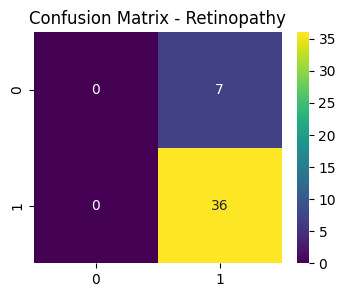

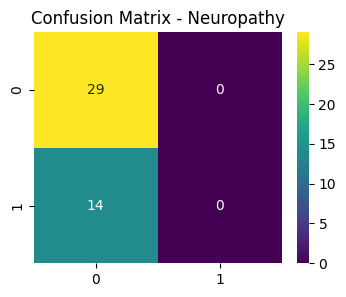

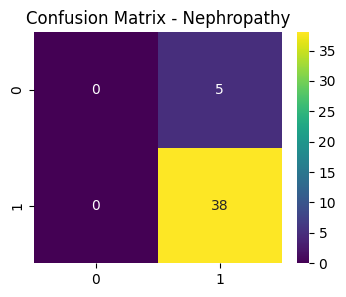

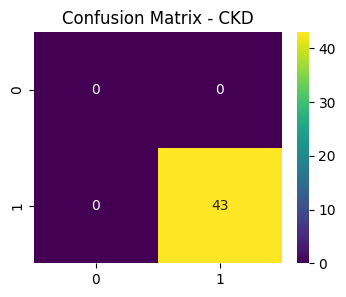

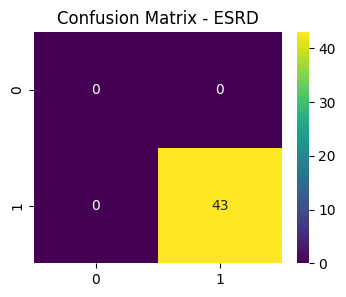

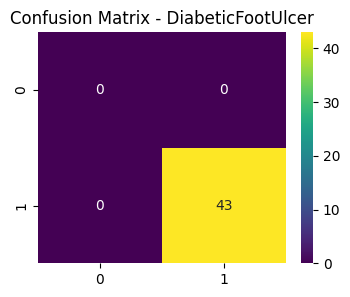

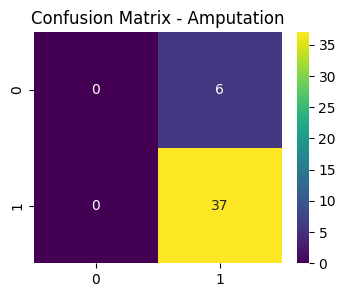

In [ ]:
# Confusion matrix per label
for i, label in enumerate(target_cols):
    cm = multilabel_confusion_matrix(y_true[:,i], y_pred_bin[:,i])[0]
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.title(f"Confusion Matrix - {label}")
    plt.show()



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


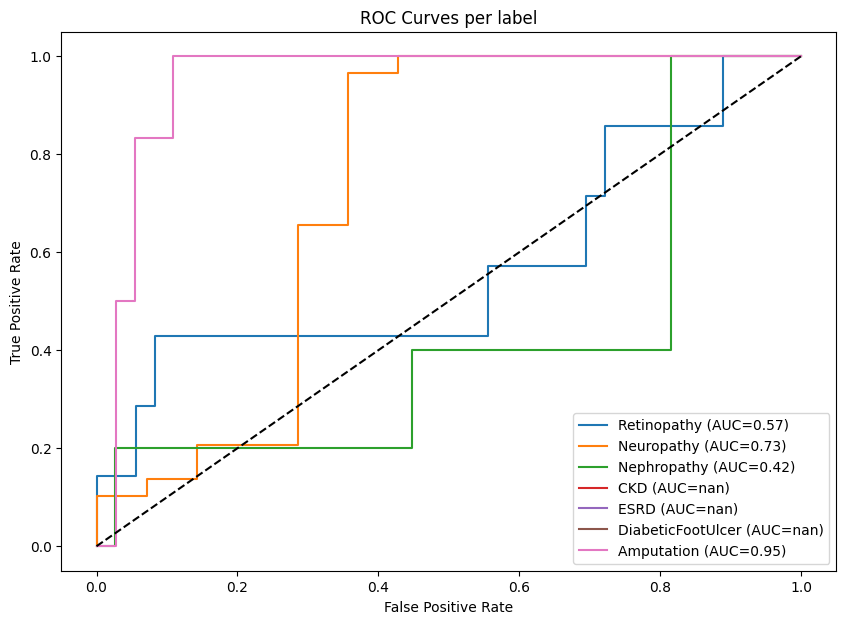

In [ ]:
# Optional: ROC curves
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,7))
for i, label in enumerate(target_cols):
    fpr, tpr, _ = roc_curve(y_true[:,i], y_pred[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per label")
plt.legend()
plt.show()


# BioClinicalBert + RAG(pdf)

Clinical notes (2 columns)

        ↓

Combine text columns

        ↓

Retrieve context from
PDF (RAG)

        ↓

Augmented text = note + retrieved knowledge

        ↓

Tokenize

        ↓

BioClinicalBERT

        ↓
        
Multi-label classification

In [15]:
!pip install transformers
!pip install sentence-transformers
!pip install faiss-cpu
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.4/331.4 kB 27.6 MB/s eta 0:00:00


# Import Libraries

In [16]:
import torch
import pandas as pd
import numpy as np

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer

import faiss
from pypdf import PdfReader

# Load  PDF Knowledge Base

In [17]:
def load_pdf(pdf_path):

    reader = PdfReader(pdf_path)
    text = ""

    for page in reader.pages:
        if page.extract_text():
            text += page.extract_text() + "\n"

    return text


pdf_text = load_pdf("/content/drive/MyDrive/fact-sheet-diabetes-related-complications.pdf")

print(pdf_text[:500])

Looking after your diabetes is very important for long-term health. If your diabetes is well 
managed and you take care of your general health, you can reduce the risk of diabetes-related 
complications in the future.
Diabetes-related complications
NDSS Helpline 1800 637 700 
ndss.com.au
Version 4.0.0-r1, June 2025. First published June 2016. NDSSFS015
What are the most common 
complications of diabetes?
Diabetes-related complications can include 
damage to:
• the large blood vessels (also known


# Split PDF into Chuncks

In [18]:
def split_text(text, chunk_size=200):

    words = text.split()
    chunks = []

    for i in range(0, len(words), chunk_size):

        chunk = " ".join(words[i:i+chunk_size])
        chunks.append(chunk)

    return chunks


kb_chunks = split_text(pdf_text)

print("Number of chunks:", len(kb_chunks))

Number of chunks: 9


# Create embeddings for knowledge base

In [19]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

kb_embeddings = embed_model.encode(
    kb_chunks,
    convert_to_numpy=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# Build FAISS Retrieval Index

In [20]:
dimension = kb_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(kb_embeddings)

# Mask complications in text columns

In [21]:
import re


complications = ['Neuropathy',
    'Retinopathy',
    'Nephropathy',
    'CKD',
    'ESRD',
    'DiabeticFootUlcer',
    'Amputation']

In [22]:
def mask_labels(text):
    text = str(text).lower()

    for word in complications:
        pattern = r"\b" + re.escape(word) + r"\b"
        text = re.sub(pattern, "[MASK]", text)

    return text

In [23]:
df['DiagnosisText_orig'] = df['DiagnosisText_orig'].astype(str)
df['concatDiagnosisText_Orig'] = df['concatDiagnosisText_Orig'].astype(str)
# mask label words
df['DiagnosisText_orig'] = df['DiagnosisText_orig'].apply(mask_labels)
df['concatDiagnosisText_Orig'] = df['concatDiagnosisText_Orig'].apply(mask_labels)
# convert to list for tokenizer
# texts_masked = texts_masked.tolist()

# Combine knowlege base with CPCSSN columns

In [24]:
df["combined_text"] = (
    df["DiagnosisText_orig"].fillna("") + " " +
    df["concatDiagnosisText_Orig"].fillna("")
)

texts = df["combined_text"].astype(str).tolist()

# Retrieve knowledge (RAG)

In [25]:
def retrieve_context(query, k=3):

    query_embedding = embed_model.encode([query])

    distances, indices = index.search(query_embedding, k)

    retrieved_chunks = [kb_chunks[i] for i in indices[0]]

    return " ".join(retrieved_chunks)

# Create RAG augmented text

In [26]:
rag_texts = []

for text in texts:

    context = retrieve_context(text)

    augmented_text = text + " [KNOWLEDGE] " + context

    rag_texts.append(augmented_text)

# Prepare Multi-Label Targets

In [27]:
y = df[
[
"Retinopathy",
"Neuropathy",
"Nephropathy",
"CKD",
"ESRD",
"DiabeticFootUlcer",
"Amputation"
]
]


labels = df[
[
"Retinopathy",
"Neuropathy",
"Nephropathy",
"CKD",
"ESRD",
"DiabeticFootUlcer",
"Amputation"
]
].values

labels = torch.tensor(labels).float()

# Create custom Dataset

In [28]:
import torch
from torch.utils.data import Dataset

class ClinicalDataset(Dataset):
    """
    PyTorch Dataset for clinical text data (CPCSSN) for multi-label classification
    using BioClinicalBERT.

    Args:
        texts (list or np.array): List of clinical text strings
        labels (list or np.array): Multi-label targets (0/1 arrays)
        tokenizer (transformers tokenizer): Pretrained BERT tokenizer
        max_len (int): Maximum sequence length for tokenization
    """

    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Ensure text is a string
        text = str(self.texts[idx])
        # Convert label to float tensor (for multi-label BCE loss)
        label = torch.tensor(self.labels[idx], dtype=torch.float)

        # Tokenize the text
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        # Squeeze batch dimension (from return_tensors='pt')
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)
        # Handle optional token_type_ids (some BERT variants do not use it)
        token_type_ids = encoding.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.squeeze(0)

        # Return a single dictionary for easy DataLoader batching
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "token_type_ids": token_type_ids,
            "labels": label
        }

# Create Stratification Label

In [29]:
# y is dataframe with complication columns
stratify_label = (y.sum(axis=1) > 0).astype(int)
# 1 if patient has any condition, else 0


# Stratified K-Fold

In [30]:
from sklearn.model_selection import StratifiedKFold


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train / Validation / Test Split (70 / 15 / 15)

In [ ]:
Raw Dataset
     │
     ▼
Train / Validation / Test Split
     │
     ├── Train Dataset
     │        │
     │        └── Train DataLoader
     │
     ├── Validation Dataset
     │        │
     │        └── Validation DataLoader
     │
     └── Test Dataset
              │
              └── Test DataLoader

# Preparing Data For training

In [31]:
from transformers import AutoTokenizer
from torch.utils.data import Subset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# Create full dataset
dataset = ClinicalDataset(texts, labels, tokenizer, max_len=64)



# Hold out 15% test set
indices = np.arange(len(dataset))
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.15,
    stratify=stratify_label,
    random_state=42
)

# Create Subset & DataLoader for test set
test_dataset = Subset(dataset, test_idx)
test_loader  = DataLoader(test_dataset, batch_size=16)

# Stratified K-Fold on remaining 85% (train + validation)
train_val_labels = stratify_label[train_val_idx]  # stratify only on train+val set
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)




config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

# Looping for Stratified K-Fold Cross Validation

In [32]:
for fold, (train_idx_rel, val_idx_rel) in enumerate(skf.split(train_val_idx, train_val_labels)):
    print(f"Fold {fold + 1}")

    # Convert relative indices to absolute indices in the full dataset
    train_fold_idx = train_val_idx[train_idx_rel]
    val_fold_idx   = train_val_idx[val_idx_rel]

    # Create Subsets for this fold
    train_fold_dataset = Subset(dataset, train_fold_idx)
    val_fold_dataset   = Subset(dataset, val_fold_idx)

    # DataLoaders for this fold
    train_loader = DataLoader(train_fold_dataset, batch_size=16, shuffle=True)
    val_loader   = DataLoader(val_fold_dataset, batch_size=16)


Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


# Load BioClinicalBERT

In [33]:
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

In [34]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=7,
    problem_type="multi_label_classification"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [35]:
loss_fn = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# Train Loop with Validation

In [36]:
model.train()

for batch in train_loader:

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    logits = outputs.logits

    loss = loss_fn(logits, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

/tmp/ipykernel_545/1679634486.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(self.labels[idx], dtype=torch.float)


# Validation Loop

In [37]:
model.eval()

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
          input_ids=input_ids,
          attention_mask=attention_mask
          )

        logits = outputs.logits

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).int()

/tmp/ipykernel_545/1679634486.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(self.labels[idx], dtype=torch.float)


# Final Evaluation on Test Set

In [38]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
import numpy as np

model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        # Convert logits → probabilities
        probs = torch.sigmoid(logits)

        # Convert probabilities → predictions
        preds = (probs > 0.5).int()

        # Move to CPU for metrics
        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

# Combine all batches
all_labels = np.vstack(all_labels)
all_preds = np.vstack(all_preds)
all_probs = np.vstack(all_probs)

/tmp/ipykernel_545/1679634486.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(self.labels[idx], dtype=torch.float)


# Compute Evaluation Metrics

In [39]:
f1_micro = f1_score(all_labels, all_preds, average="micro")
f1_macro = f1_score(all_labels, all_preds, average="macro")

roc_auc = roc_auc_score(all_labels, all_probs, average="macro")

accuracy = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", accuracy)
print("Test F1 Micro:", f1_micro)
print("Test F1 Macro:", f1_macro)
print("Test ROC-AUC:", roc_auc)

Test Accuracy: 0.9891975308641975
Test F1 Micro: 0.0
Test F1 Macro: 0.0
Test ROC-AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [40]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    hamming_loss,
    accuracy_score
)

# Overall metrics
f1_micro = f1_score(all_labels, all_preds, average="micro")
f1_macro = f1_score(all_labels, all_preds, average="macro")
h_loss = hamming_loss(all_labels, all_preds)
subset_acc = accuracy_score(all_labels, all_preds)
roc_auc_macro = roc_auc_score(all_labels, all_probs, average="macro")

print("Overall Metrics")
print("Micro F1:", f1_micro)
print("Macro F1:", f1_macro)
print("Hamming Loss:", h_loss)
print("Subset Accuracy:", subset_acc)
print("Macro ROC-AUC:", roc_auc_macro)

Overall Metrics
Micro F1: 0.0
Macro F1: 0.0
Hamming Loss: 0.0016534391534391533
Subset Accuracy: 0.9891975308641975
Macro ROC-AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [41]:
label_names = [
"Retinopathy",
"Neuropathy",
"Nephropathy",
"CKD",
"ESRD",
"DiabeticFootUlcer",
"Amputation"
]

f1_per_label = f1_score(all_labels, all_preds, average=None)
precision_per_label = precision_score(all_labels, all_preds, average=None)
recall_per_label = recall_score(all_labels, all_preds, average=None)
roc_auc_per_label = roc_auc_score(all_labels, all_probs, average=None)

for i, label in enumerate(label_names):
    print(label)
    print("F1:", f1_per_label[i])
    print("Precision:", precision_per_label[i])
    print("Recall:", recall_per_label[i])
    print("ROC-AUC:", roc_auc_per_label[i])
    print()

Retinopathy
F1: 0.0
Precision: 0.0
Recall: 0.0
ROC-AUC: 0.9855892949047864

Neuropathy
F1: 0.0
Precision: 0.0
Recall: 0.0
ROC-AUC: 0.9414222015708911

Nephropathy
F1: 0.0
Precision: 0.0
Recall: 0.0
ROC-AUC: 0.9221621157478963

CKD
F1: 0.0
Precision: 0.0
Recall: 0.0
ROC-AUC: 0.9055827116027785

ESRD
F1: 0.0
Precision: 0.0
Recall: 0.0
ROC-AUC: nan

DiabeticFootUlcer
F1: 0.0
Precision: 0.0
Recall: 0.0
ROC-AUC: 0.898224395265054

Amputation
F1: 0.0
Precision: 0.0
Recall: 0.0
ROC-AUC: 0.9201133144475921



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

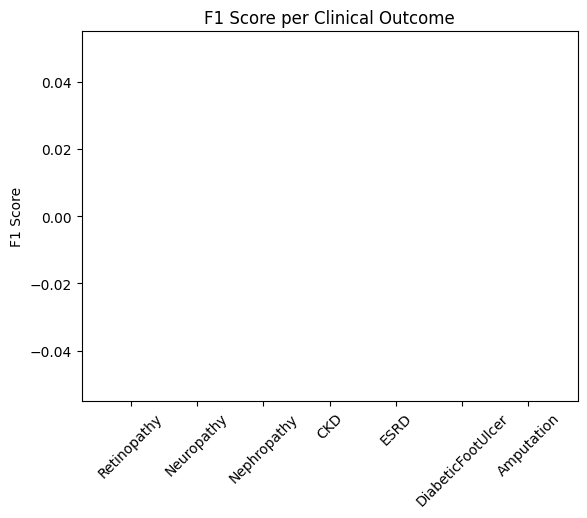

In [42]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(label_names, f1_per_label)

plt.xticks(rotation=45)

plt.ylabel("F1 Score")

plt.title("F1 Score per Clinical Outcome")

plt.show()

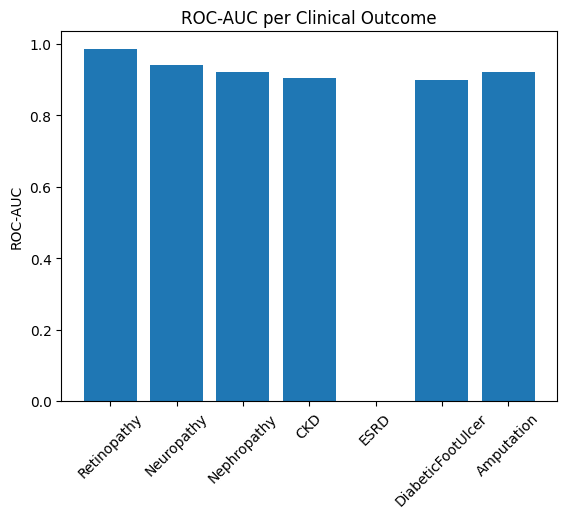

In [43]:
plt.figure()

plt.bar(label_names, roc_auc_per_label)

plt.xticks(rotation=45)

plt.ylabel("ROC-AUC")

plt.title("ROC-AUC per Clinical Outcome")

plt.show()

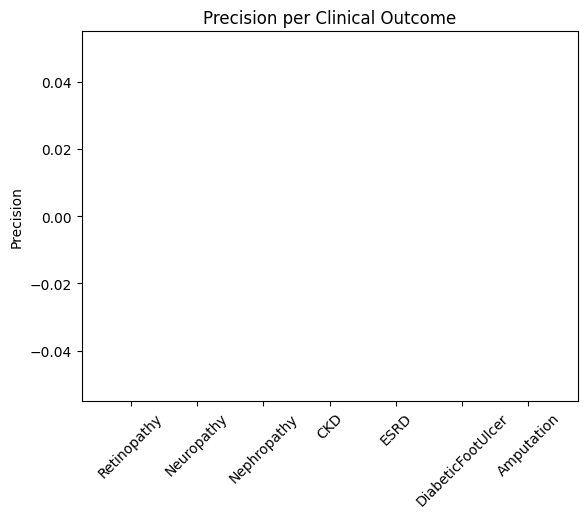

In [44]:
plt.figure()

plt.bar(label_names, precision_per_label)

plt.xticks(rotation=45)

plt.ylabel("Precision")

plt.title("Precision per Clinical Outcome")

plt.show()

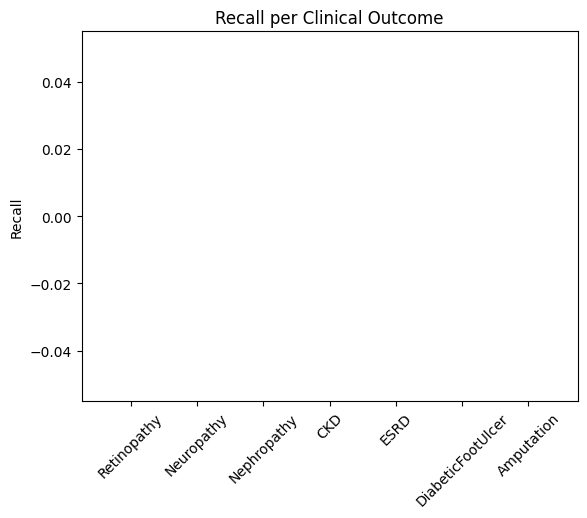

In [45]:
plt.figure()

plt.bar(label_names, recall_per_label)

plt.xticks(rotation=45)

plt.ylabel("Recall")

plt.title("Recall per Clinical Outcome")

plt.show()

In [46]:
for i, label in enumerate(label_names):

    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])

    plt.figure()

    plt.plot(fpr, tpr)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"ROC Curve - {label}")

    plt.show()

NameError: name 'roc_curve' is not defined